# Smith09 Network Correlations and DMN x ECN Interaction

This notebook reviews two follow-up analyses for the N=27 resting-state tACS sample:

1. Smith09 network-to-network timecourse correlations from dual-regression stage 1.
2. The Smith09 DMN x ECN physio-physio interaction stage-2 randomise analysis.

The notebook reads only GitHub-tracked summaries under `derivatives/fsl/network_correlation_summary` and `derivatives/fsl/ppi_randomise_summary`. It ignores TFCE and treats FSL corrected-p images as `1 - p` maps.


In [1]:
from pathlib import Path
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image as IPyImage

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
NETWORK_DIR = PROJECT_ROOT / 'derivatives' / 'fsl' / 'network_correlation_summary'
PPI_DIR = PROJECT_ROOT / 'derivatives' / 'fsl' / 'ppi_randomise_summary'
CORRP_THRESHOLD = 0.95
CONDITION_ORDER = ['sham', 'rtpj', 'vlpfc', 'both']
CONDITION_LABELS = {'sham': 'Sham', 'rtpj': 'RTPJ', 'vlpfc': 'VLPFC', 'both': 'BOTH'}
CONTRAST_ORDER = [
    'both-minus-sham',
    'both-minus-rtpj',
    'both-minus-vlpfc',
    'rtpj-minus-vlpfc',
    'rtpj-minus-sham',
    'vlpfc-minus-sham',
    'both-minus-mean-rtpj-vlpfc',
]

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

def display_figure(fig, dpi=150):
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    display(IPyImage(data=buf.getvalue()))

def pretty_contrast(value):
    return (value.replace('both', 'BOTH')
                 .replace('rtpj', 'RTPJ')
                 .replace('vlpfc', 'VLPFC')
                 .replace('sham', 'Sham')
                 .replace('minus', '-'))


## Load Tracked Summaries

In [2]:
summary_path = NETWORK_DIR / 'task-rest_analysis-smith09_denoised_network-correlation_summary.tsv'
contrast_path = NETWORK_DIR / 'task-rest_analysis-smith09_denoised_network-correlation_condition-contrasts.tsv'
run_path = NETWORK_DIR / 'task-rest_analysis-smith09_denoised_network-correlation_run-values.tsv'
ppi_path = PPI_DIR / 'task-rest_ppi-dmn-ecn_randomise_peak_summary.tsv'

for path in [summary_path, contrast_path, run_path, ppi_path]:
    if not path.exists():
        raise FileNotFoundError(path)

summary = pd.read_csv(summary_path, sep='	')
contrasts = pd.read_csv(contrast_path, sep='	')
run_values = pd.read_csv(run_path, sep='	')
ppi = pd.read_csv(ppi_path, sep='	')

numeric_cols = ['mean_delta_fisher_z', 'sd_delta_fisher_z', 'sem_delta_fisher_z', 't_1sample', 'p_signflip_two_sided']
for col in numeric_cols:
    summary[col] = pd.to_numeric(summary[col], errors='coerce')
for col in ['sham_z', 'rtpj_z', 'vlpfc_z', 'both_z', 'delta_fisher_z']:
    contrasts[col] = pd.to_numeric(contrasts[col], errors='coerce')
for col in ['r', 'fisher_z']:
    run_values[col] = pd.to_numeric(run_values[col], errors='coerce')
ppi['peak_corrp'] = pd.to_numeric(ppi['peak_corrp'], errors='coerce')

n_subjects = contrasts.loc[contrasts['complete'].astype(str).str.lower() == 'true', 'participant'].nunique()
network_pairs = summary['network_pair'].nunique()
ppi_sig = ppi[ppi['peak_gt_threshold'].astype(str).str.lower() == 'true'].copy()

print(f'Network-correlation subjects: N={n_subjects}')
print(f'Network pairs: {network_pairs}; summary rows: {len(summary)}')
print(f'PPI randomise rows: {len(ppi)}; significant corrected maps: {len(ppi_sig)}')


Network-correlation subjects: N=27
Network pairs: 36; summary rows: 504
PPI randomise rows: 14; significant corrected maps: 2


## DMN and ECN Timecourse Correlation

The primary non-image question is whether DMN-ECN coupling changes by stimulation condition. Values below are Fisher-z transformed correlations. `full` is the ordinary Pearson correlation between the two stage-1 timecourses; `partial` is the precision-matrix partial correlation controlling the other Smith09 networks in the same run.


In [3]:
dmn_ecn_summary = summary[summary['network_pair'].eq('dmn__ecn')].copy()
dmn_ecn_summary['contrast_label'] = pd.Categorical(
    dmn_ecn_summary['condition_contrast'].map(pretty_contrast),
    categories=[pretty_contrast(c) for c in CONTRAST_ORDER],
    ordered=True,
)
display(
    dmn_ecn_summary.sort_values(['correlation_type', 'contrast_label'])[
        ['correlation_type', 'condition_contrast', 'n', 'mean_delta_fisher_z', 'sem_delta_fisher_z', 't_1sample', 'p_signflip_two_sided']
    ].style.format({
        'mean_delta_fisher_z': '{:.4f}',
        'sem_delta_fisher_z': '{:.4f}',
        't_1sample': '{:.2f}',
        'p_signflip_two_sided': '{:.3f}',
    })
)


,correlation_type,condition_contrast,n,mean_delta_fisher_z,sem_delta_fisher_z,t_1sample,p_signflip_two_sided
28,full,both-minus-sham,27,0.0123,0.0317,0.39,0.699
29,full,both-minus-rtpj,27,-0.0096,0.0343,-0.28,0.778
30,full,both-minus-vlpfc,27,-0.0157,0.0286,-0.55,0.589
31,full,rtpj-minus-vlpfc,27,-0.0060,0.0303,-0.20,0.845
32,full,rtpj-minus-sham,27,0.0220,0.0259,0.85,0.404
33,full,vlpfc-minus-sham,27,0.0280,0.0297,0.94,0.354
34,full,both-minus-mean-rtpj-vlpfc,27,-0.0126,0.0277,-0.46,0.650
280,partial,both-minus-sham,27,0.0153,0.0290,0.53,0.601
281,partial,both-minus-rtpj,27,-0.0027,0.0267,-0.10,0.924
282,partial,both-minus-vlpfc,27,-0.0252,0.0279,-0.90,0.380


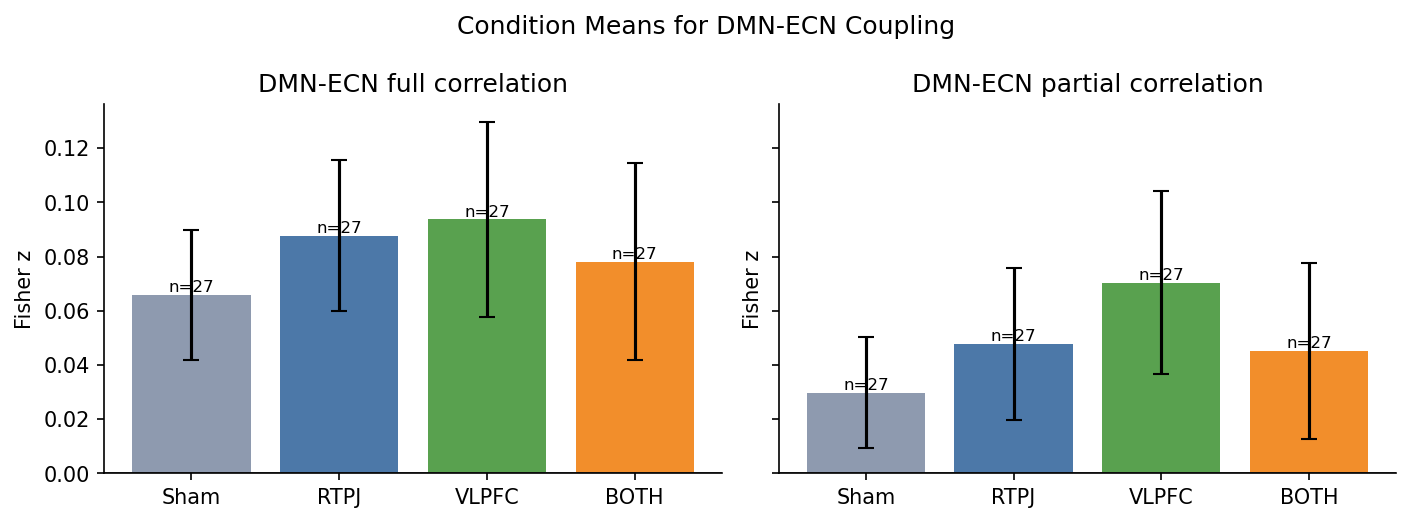

In [4]:
dmn_ecn_runs = run_values[run_values['network_pair'].eq('dmn__ecn')].copy()
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.5), sharey=True)
for ax, corr_type in zip(axes, ['full', 'partial']):
    data = dmn_ecn_runs[dmn_ecn_runs['correlation_type'].eq(corr_type)].copy()
    grouped = data.groupby('condition', observed=False)['fisher_z'].agg(['mean', 'sem', 'count']).reindex(CONDITION_ORDER)
    x = np.arange(len(CONDITION_ORDER))
    ax.bar(x, grouped['mean'], yerr=grouped['sem'], capsize=4, color=['#8e9aaf', '#4c78a8', '#59a14f', '#f28e2b'])
    ax.axhline(0, color='0.25', linewidth=0.8)
    ax.set_xticks(x, [CONDITION_LABELS[c] for c in CONDITION_ORDER])
    ax.set_title(f'DMN-ECN {corr_type} correlation')
    ax.set_ylabel('Fisher z')
    for i, row in enumerate(grouped.itertuples()):
        ax.text(i, row.mean, f'n={int(row.count)}', ha='center', va='bottom' if row.mean >= 0 else 'top', fontsize=8)
fig.suptitle('Condition Means for DMN-ECN Coupling')
fig.tight_layout()
display_figure(fig)


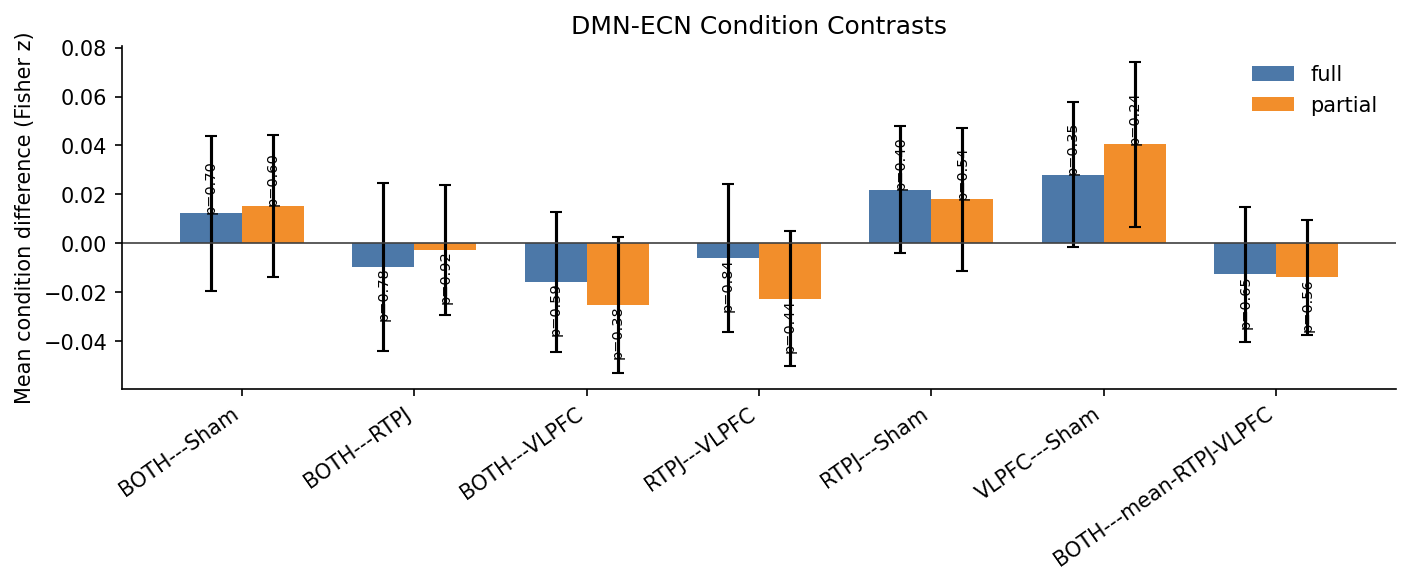

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 4.0))
plot_data = dmn_ecn_summary.copy()
plot_data['condition_contrast'] = pd.Categorical(plot_data['condition_contrast'], categories=CONTRAST_ORDER, ordered=True)
plot_data = plot_data.sort_values(['condition_contrast', 'correlation_type'])
width = 0.36
x = np.arange(len(CONTRAST_ORDER))
for offset, corr_type, color in [(-width/2, 'full', '#4c78a8'), (width/2, 'partial', '#f28e2b')]:
    data = plot_data[plot_data['correlation_type'].eq(corr_type)].set_index('condition_contrast').reindex(CONTRAST_ORDER)
    ax.bar(x + offset, data['mean_delta_fisher_z'], width=width, yerr=data['sem_delta_fisher_z'], capsize=3, label=corr_type, color=color)
    for xpos, row in zip(x + offset, data.itertuples()):
        ax.text(xpos, row.mean_delta_fisher_z, f'p={row.p_signflip_two_sided:.2f}', ha='center', va='bottom' if row.mean_delta_fisher_z >= 0 else 'top', fontsize=7, rotation=90)
ax.axhline(0, color='0.25', linewidth=0.8)
ax.set_xticks(x, [pretty_contrast(c) for c in CONTRAST_ORDER], rotation=35, ha='right')
ax.set_ylabel('Mean condition difference (Fisher z)')
ax.set_title('DMN-ECN Condition Contrasts')
ax.legend(frameon=False)
fig.tight_layout()
display_figure(fig)


## Broader Smith09 Network-Correlation Scan

This is a descriptive screen across all non-cerebellar Smith09 network pairs. It is not a replacement for the focused DMN-ECN question; it helps reveal whether any other pair has a stronger condition pattern.


In [6]:
top = summary.sort_values('p_signflip_two_sided').head(20).copy()
display(
    top[['correlation_type', 'network_pair', 'condition_contrast', 'n', 'mean_delta_fisher_z', 't_1sample', 'p_signflip_two_sided']]
    .style.format({'mean_delta_fisher_z': '{:.4f}', 't_1sample': '{:.2f}', 'p_signflip_two_sided': '{:.4f}'})
)


,correlation_type,network_pair,condition_contrast,n,mean_delta_fisher_z,t_1sample,p_signflip_two_sided
321,partial,ecn__right-fpn,both-minus-mean-rtpj-vlpfc,27,-0.0706,-3.67,0.0009
317,partial,ecn__right-fpn,both-minus-vlpfc,27,-0.1018,-3.80,0.0010
304,partial,dmn__sensorimotor,rtpj-minus-vlpfc,27,-0.0722,-3.27,0.0030
65,full,ecn__right-fpn,both-minus-vlpfc,27,-0.1171,-2.96,0.0060
63,full,ecn__right-fpn,both-minus-sham,27,-0.1057,-2.57,0.0084
433,partial,primary-visual__ecn,both-minus-mean-rtpj-vlpfc,27,-0.0615,-2.79,0.0087
464,partial,primary-visual__sensorimotor,both-minus-vlpfc,27,-0.0882,-2.73,0.0093
428,partial,primary-visual__ecn,both-minus-rtpj,27,-0.0747,-2.78,0.0106
69,full,ecn__right-fpn,both-minus-mean-rtpj-vlpfc,27,-0.0859,-2.53,0.0131
302,partial,dmn__sensorimotor,both-minus-rtpj,27,0.0701,2.41,0.0176


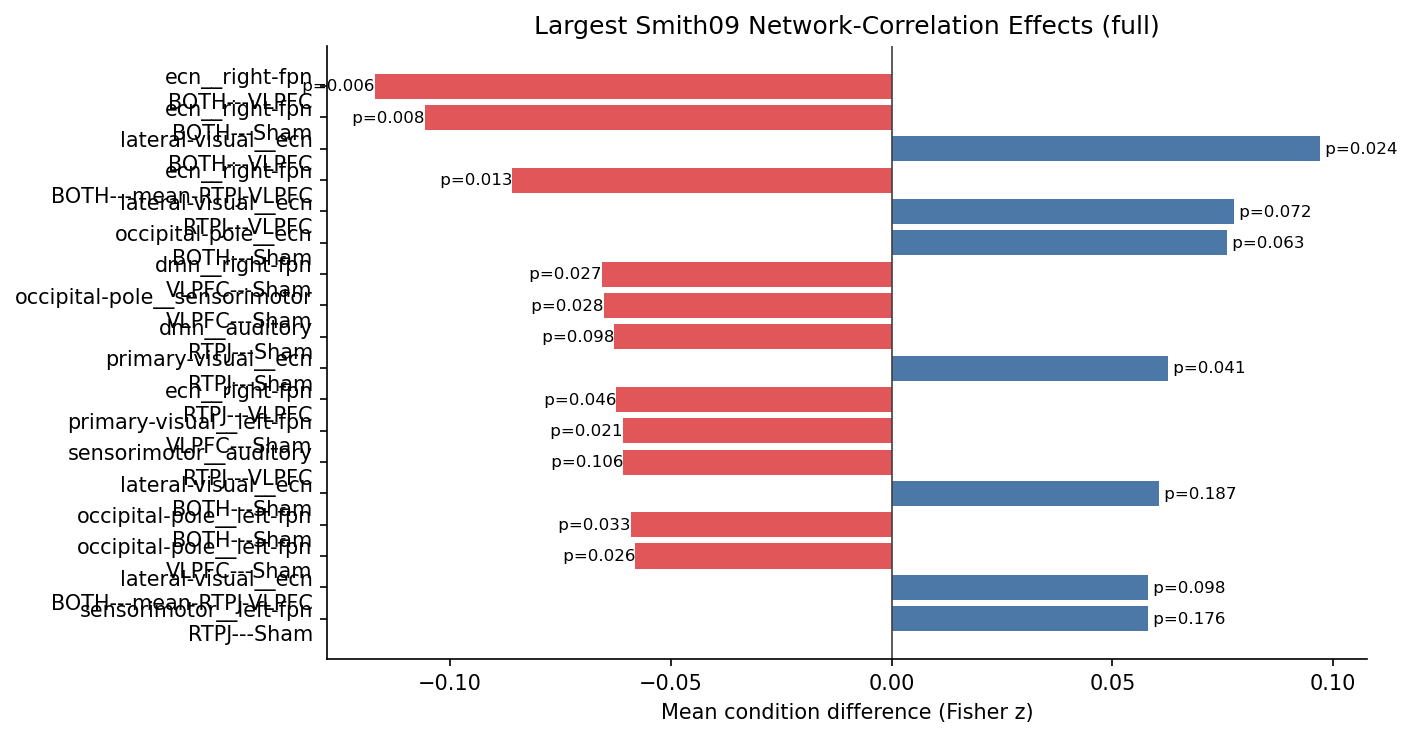

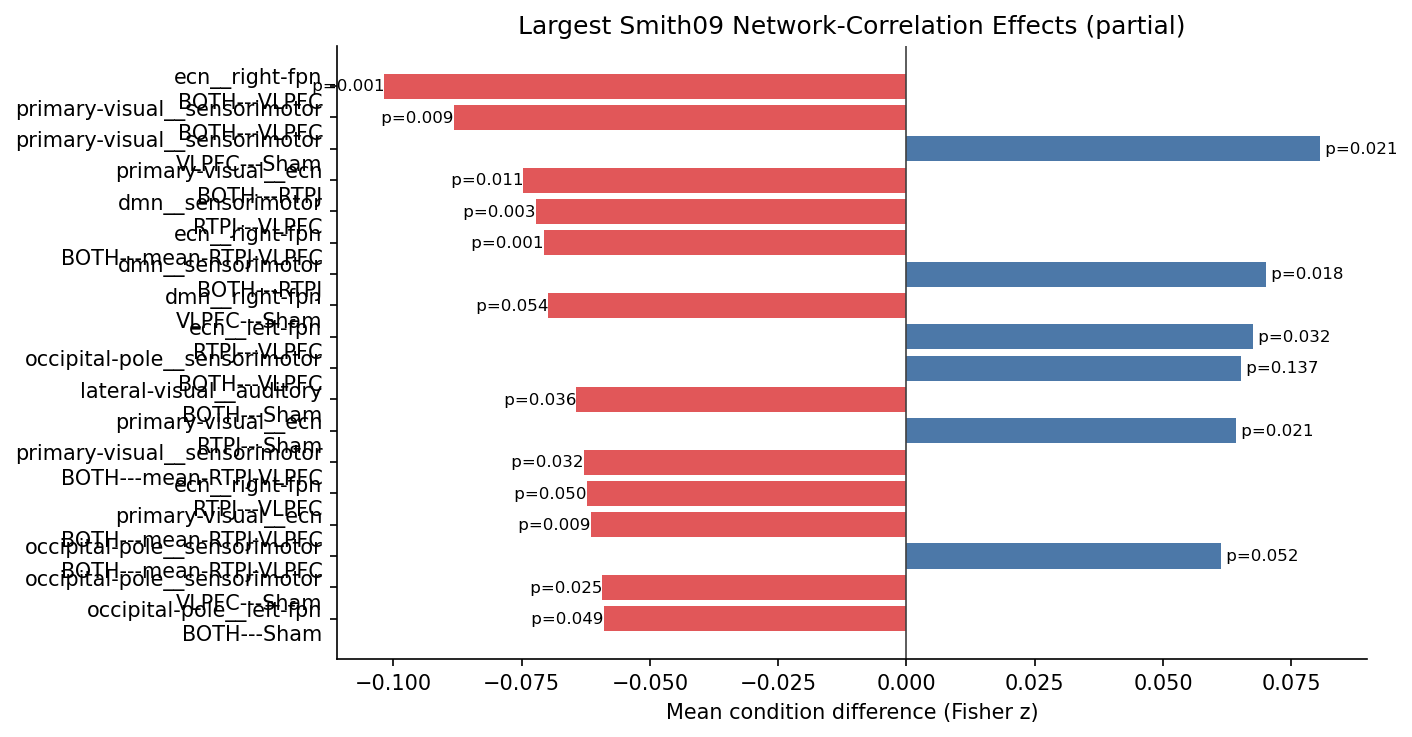

In [7]:
for corr_type in ['full', 'partial']:
    data = summary[summary['correlation_type'].eq(corr_type)].copy()
    data['abs_effect'] = data['mean_delta_fisher_z'].abs()
    # For display, keep the 18 pair/contrast cells with the largest absolute mean effects.
    top_cells = data.nlargest(18, 'abs_effect')
    labels = [f"{row.network_pair}\n{pretty_contrast(row.condition_contrast)}" for row in top_cells.itertuples()]
    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    colors = np.where(top_cells['mean_delta_fisher_z'] >= 0, '#4c78a8', '#e15759')
    y = np.arange(len(top_cells))
    ax.barh(y, top_cells['mean_delta_fisher_z'], color=colors)
    ax.axvline(0, color='0.25', linewidth=0.8)
    ax.set_yticks(y, labels)
    ax.invert_yaxis()
    ax.set_xlabel('Mean condition difference (Fisher z)')
    ax.set_title(f'Largest Smith09 Network-Correlation Effects ({corr_type})')
    for ypos, row in enumerate(top_cells.itertuples()):
        ax.text(row.mean_delta_fisher_z, ypos, f' p={row.p_signflip_two_sided:.3f}', va='center', ha='left' if row.mean_delta_fisher_z >= 0 else 'right', fontsize=8)
    fig.tight_layout()
    display_figure(fig)


## DMN x ECN Interaction Randomise Results

The PPI-style analysis appends a centered `DMN x ECN` interaction timecourse to the Smith09 stage-1 design and reruns stage 2. Component 11 is the interaction map. The table below audits all seven condition contrasts and both directions. Brain panels are shown only for corrected cluster-extent maps with peak `1 - p > 0.95`.


In [8]:
ppi_display = ppi.sort_values('peak_corrp', ascending=False).copy()
display(
    ppi_display[['condition_contrast', 'design_contrast', 'direction', 'inference', 'peak_corrp', 'peak_gt_threshold', 'status', 'copied_image', 'roi_values_tsv']]
    .style.format({'peak_corrp': '{:.4f}'})
)


,condition_contrast,design_contrast,direction,inference,peak_corrp,peak_gt_threshold,status,copied_image,roi_values_tsv
7,rtpj-minus-vlpfc,C2,negative,cluster-extent,0.9816,True,ok,derivatives/fsl/ppi_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DmnEcnPpiComp0011RtpjMinusVlpfcNegativeClusterExtentCorrp_stat-corrp_statmap.nii.gz,derivatives/fsl/ppi_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DmnEcnPpiComp0011RtpjMinusVlpfcNegativeClusterExtentCorrp_stat-stage2Beta_timeseries.tsv
12,both-minus-mean-rtpj-vlpfc,C1,positive,cluster-extent,0.9752,True,ok,derivatives/fsl/ppi_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DmnEcnPpiComp0011BothMinusMeanRtpjVlpfcPositiveClusterExtentCorrp_stat-corrp_statmap.nii.gz,derivatives/fsl/ppi_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DmnEcnPpiComp0011BothMinusMeanRtpjVlpfcPositiveClusterExtentCorrp_stat-stage2Beta_timeseries.tsv
2,both-minus-rtpj,C1,positive,cluster-extent,0.9358,False,ok,nan,nan
4,both-minus-vlpfc,C1,positive,cluster-extent,0.7086,False,ok,nan,nan
10,vlpfc-minus-sham,C1,positive,cluster-extent,0.5560,False,ok,nan,nan
0,both-minus-sham,C1,positive,cluster-extent,0.5456,False,ok,nan,nan
5,both-minus-vlpfc,C2,negative,cluster-extent,0.5254,False,ok,nan,nan
6,rtpj-minus-vlpfc,C1,positive,cluster-extent,0.5198,False,ok,nan,nan
13,both-minus-mean-rtpj-vlpfc,C2,negative,cluster-extent,0.5158,False,ok,nan,nan
11,vlpfc-minus-sham,C2,negative,cluster-extent,0.2990,False,ok,nan,nan


### RTPJ---VLPFC | negative | peak 1-p=0.9816

Map: `derivatives/fsl/ppi_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DmnEcnPpiComp0011RtpjMinusVlpfcNegativeClusterExtentCorrp_stat-corrp_statmap.nii.gz`  
ROI values: `derivatives/fsl/ppi_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DmnEcnPpiComp0011RtpjMinusVlpfcNegativeClusterExtentCorrp_stat-stage2Beta_timeseries.tsv`

Thresholded voxels: 13

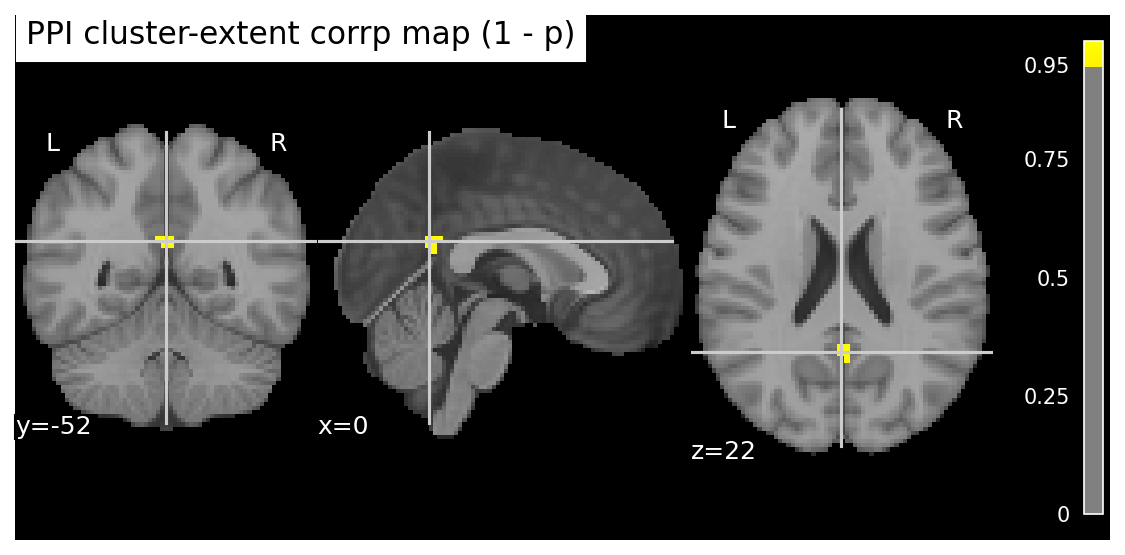

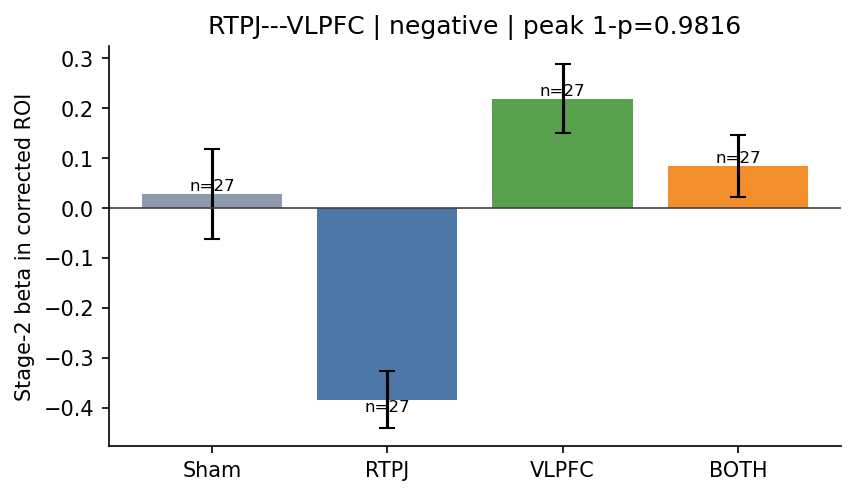

### BOTH---mean-RTPJ-VLPFC | positive | peak 1-p=0.9752

Map: `derivatives/fsl/ppi_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DmnEcnPpiComp0011BothMinusMeanRtpjVlpfcPositiveClusterExtentCorrp_stat-corrp_statmap.nii.gz`  
ROI values: `derivatives/fsl/ppi_randomise_summary/task-rest_space-MNI152NLin6Asym_desc-Smith09DmnEcnPpiComp0011BothMinusMeanRtpjVlpfcPositiveClusterExtentCorrp_stat-stage2Beta_timeseries.tsv`

Thresholded voxels: 11

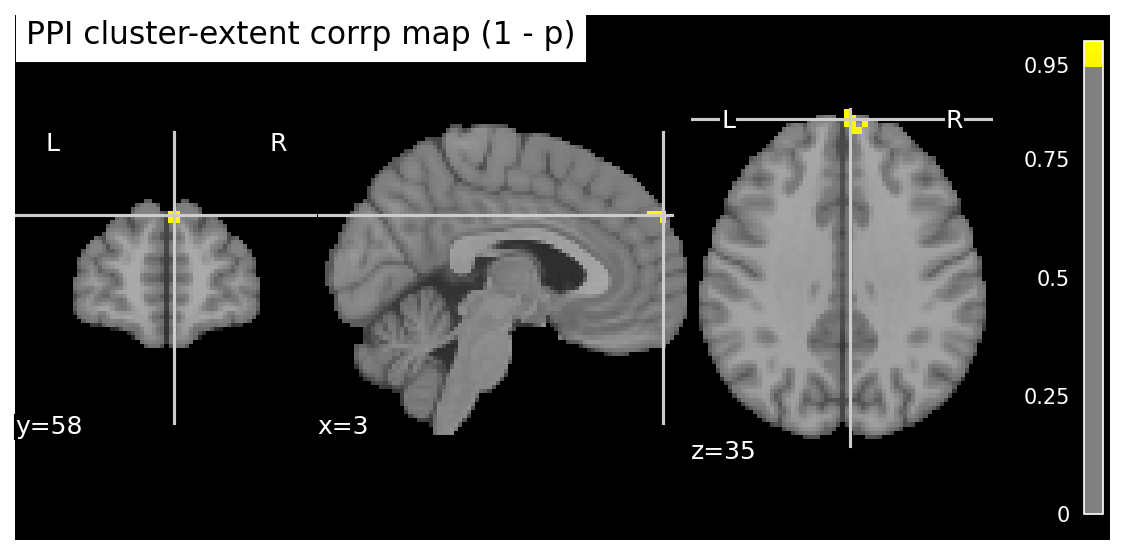

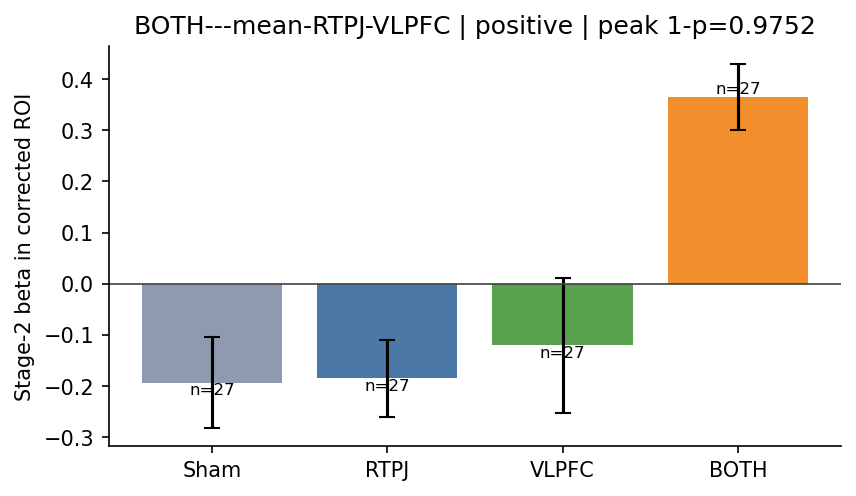

In [9]:
try:
    import nibabel as nib
    from nilearn import datasets, image, plotting
    MNI_TEMPLATE = datasets.load_mni152_template(resolution=2)
    HAVE_NILEARN = True
except Exception as exc:
    HAVE_NILEARN = False
    print(f'Nilearn/nibabel unavailable: {exc}')

def thresholded_corrp_image(path):
    img = image.load_img(path)
    data = np.asarray(img.dataobj)
    masked = np.where(data > CORRP_THRESHOLD, data, 0.0)
    return image.new_img_like(img, masked, copy_header=True), int(np.count_nonzero(masked))

def plot_condition_bars(tsv_path, title):
    values = pd.read_csv(tsv_path, sep='	')
    values['stage2_beta'] = pd.to_numeric(values['stage2_beta'], errors='coerce')
    grouped = values.groupby('condition', observed=False)['stage2_beta'].agg(['mean', 'sem', 'count']).reindex(CONDITION_ORDER)
    fig, ax = plt.subplots(figsize=(5.8, 3.4))
    x = np.arange(len(CONDITION_ORDER))
    ax.bar(x, grouped['mean'], yerr=grouped['sem'], capsize=4, color=['#8e9aaf', '#4c78a8', '#59a14f', '#f28e2b'])
    ax.axhline(0, color='0.25', linewidth=0.8)
    ax.set_xticks(x, [CONDITION_LABELS[c] for c in CONDITION_ORDER])
    ax.set_ylabel('Stage-2 beta in corrected ROI')
    ax.set_title(title)
    for i, row in enumerate(grouped.itertuples()):
        ax.text(i, row.mean, f'n={int(row.count)}', ha='center', va='bottom' if row.mean >= 0 else 'top', fontsize=8)
    fig.tight_layout()
    display_figure(fig)

sig_ppi = ppi[ppi['peak_gt_threshold'].astype(str).str.lower().eq('true')].copy()
if sig_ppi.empty:
    display(Markdown('No PPI maps crossed `1-p > 0.95`.'))
else:
    for row in sig_ppi.sort_values('peak_corrp', ascending=False).itertuples():
        title = f"{pretty_contrast(row.condition_contrast)} | {row.direction} | peak 1-p={row.peak_corrp:.4f}"
        display(Markdown(f"### {title}"))
        copied = PROJECT_ROOT / row.copied_image
        roi_tsv = PROJECT_ROOT / row.roi_values_tsv
        display(Markdown(f"Map: `{row.copied_image}`  \nROI values: `{row.roi_values_tsv}`"))
        if HAVE_NILEARN:
            thresh_img, n_vox = thresholded_corrp_image(copied)
            display(Markdown(f'Thresholded voxels: {n_vox}'))
            stat = plotting.plot_stat_map(
                thresh_img,
                bg_img=MNI_TEMPLATE,
                threshold=CORRP_THRESHOLD,
                display_mode='ortho',
                cut_coords=None,
                cmap='autumn',
                vmax=1.0,
                title='PPI cluster-extent corrp map (1 - p)',
            )
            display_figure(stat.frame_axes.figure, dpi=150)
            stat.close()
        plot_condition_bars(roi_tsv, title)


## Notes

- The network-correlation analysis uses timecourses, not brain images. Condition contrasts are built after Fisher-z transformation.
- The PPI ROI bars are descriptive summaries from the same corrected map shown above; they are not independent ROI tests.
- TFCE is intentionally ignored here, matching the current analysis convention.
